In [82]:
!pip install kagglehub
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [83]:
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print(path)

IMG_SIZE = 128

data = []
labels = []

dataset_path = os.path.join(path,"Dataset_BUSI_with_GT")

classes = ["benign","malignant","normal"]

for label,cls in enumerate(classes):

    folder = os.path.join(dataset_path,cls)

    for file in os.listdir(folder):

        if "mask" in file:
            continue

        img_path = os.path.join(folder,file)

        img = cv2.imread(img_path)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img/255.0

        data.append(img)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Dataset shape:",data.shape)


Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
/kaggle/input/breast-ultrasound-images-dataset
Dataset shape: (780, 128, 128, 3)


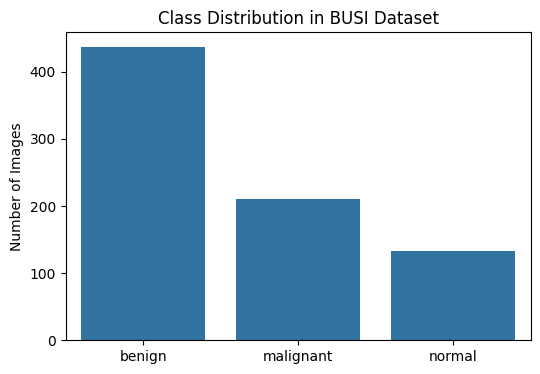

In [84]:
class_counts = pd.Series(labels).value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=["benign","malignant","normal"],
    y=class_counts.values
)

plt.title("Class Distribution in BUSI Dataset")
plt.ylabel("Number of Images")
plt.show()

In [85]:
X_train, X_temp, y_train, y_temp = train_test_split(
    data, labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

Train: (546, 128, 128, 3)
Validation: (117, 128, 128, 3)
Test: (117, 128, 128, 3)


In [86]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class weights:",class_weights)

Class weights: {0: np.float64(0.5947712418300654), 1: np.float64(1.2380952380952381), 2: np.float64(1.956989247311828)}


In [87]:
datagen = ImageDataGenerator(
    rotation_range=8,
    horizontal_flip=True,
    zoom_range=0.08
)
datagen.fit(X_train)

In [88]:
benign = X_train[y_train==0]
malignant = X_train[y_train==1]
normal = X_train[y_train==2]


target_size = len(benign)


def augment_class(images,target):

    augmented = list(images)

    while len(augmented) < target:

        img = images[np.random.randint(len(images))]
        img = img.reshape((1,128,128,3))

        aug_iter = datagen.flow(img,batch_size=1)

        augmented.append(next(aug_iter)[0])

    return np.array(augmented)


malignant_aug = augment_class(malignant,target_size)
normal_aug = augment_class(normal,target_size)

X_balanced = np.concatenate([benign,malignant_aug,normal_aug])

y_balanced = np.concatenate([
    np.zeros(len(benign)),
    np.ones(len(malignant_aug)),
    np.full(len(normal_aug),2)
])

In [89]:
def create_model():

    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(128,128,3)))
    model.add(tf.keras.layers.MaxPooling2D())

    model.add(tf.keras.layers.Conv2D(32,(3,3),activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())

    model.add(tf.keras.layers.Conv2D(64,(3,3),activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())

    model.add(tf.keras.layers.Flatten())

    model.add(tf.keras.layers.Dense(64,activation='relu'))

    model.add(tf.keras.layers.Dropout(0.4))

    model.add(tf.keras.layers.Dense(3,activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [90]:
model_baseline = create_model()

history_baseline = model_baseline.fit(
    X_train,y_train,
    epochs=12,
    validation_data=(X_val,y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 930ms/step - accuracy: 0.5330 - loss: 0.9949 - val_accuracy: 0.5556 - val_loss: 0.9465
Epoch 2/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 543ms/step - accuracy: 0.5604 - loss: 0.9436 - val_accuracy: 0.5556 - val_loss: 0.9580
Epoch 3/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 388ms/step - accuracy: 0.5604 - loss: 0.9352 - val_accuracy: 0.5556 - val_loss: 0.8917
Epoch 4/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 424ms/step - accuracy: 0.5897 - loss: 0.9232 - val_accuracy: 0.5897 - val_loss: 0.8864
Epoch 5/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 473ms/step - accuracy: 0.6264 - loss: 0.8522 - val_accuracy: 0.6410 - val_loss: 0.8331
Epoch 6/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 472ms/step - accuracy: 0.6429 - loss: 0.8069 - val_accuracy: 0.7009 - val_loss: 0.8000
Epoch 7/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 387ms/step - accuracy: 0.6832 - loss: 0.7501 - val_accuracy: 0.6581 - val_loss: 0.7532
Epoch 8/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 437ms/step - accuracy: 0.7125 - loss: 0.6900 - val_accura

In [91]:
model_aug = create_model()

history_aug = model_aug.fit(
    X_balanced,y_balanced,
    epochs=12,
    validation_data=(X_val,y_val)
)

Epoch 1/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 454ms/step - accuracy: 0.3758 - loss: 1.0936 - val_accuracy: 0.5812 - val_loss: 1.0397
Epoch 2/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 450ms/step - accuracy: 0.5098 - loss: 1.0146 - val_accuracy: 0.6410 - val_loss: 0.8619
Epoch 3/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 451ms/step - accuracy: 0.5937 - loss: 0.8885 - val_accuracy: 0.6068 - val_loss: 0.8313
Epoch 4/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 445ms/step - accuracy: 0.6481 - loss: 0.8403 - val_accuracy: 0.7009 - val_loss: 0.7549
Epoch 5/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 433ms/step - accuracy: 0.7081 - loss: 0.7154 - val_accuracy: 0.6581 - val_loss: 0.7285
Epoch 6/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 473ms/step - accuracy: 0.7331 - loss: 0.6557 - val_accuracy: 0.7094 - val_loss: 0.6662
Epoch 7/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 452ms/step - accuracy: 0.7691 - loss: 0.5600 - val_accuracy: 0.7009 - val_loss: 0.6671
Epoch 8/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 449ms/step - accuracy: 0.8192 - loss: 0.4754 - val_accu

In [92]:
model_weights = create_model()

history_weights = model_weights.fit(
    X_train,y_train,
    epochs=12,
    validation_data=(X_val,y_val),
    class_weight=class_weights
)

Epoch 1/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 499ms/step - accuracy: 0.4139 - loss: 1.0938 - val_accuracy: 0.5556 - val_loss: 1.0153
Epoch 2/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 401ms/step - accuracy: 0.5696 - loss: 1.0711 - val_accuracy: 0.5897 - val_loss: 1.0134
Epoch 3/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.4267 - loss: 1.0514 - val_accuracy: 0.6752 - val_loss: 0.9241
Epoch 4/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 492ms/step - accuracy: 0.4908 - loss: 1.0305 - val_accuracy: 0.6838 - val_loss: 0.9441
Epoch 5/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 403ms/step - accuracy: 0.6337 - loss: 0.9338 - val_accuracy: 0.4786 - val_loss: 0.9978
Epoch 6/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 478ms/step - accuracy: 0.6154 - loss: 0.8596 - val_accuracy: 0.6496 - val_loss: 0.8348
Epoch 7/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 437ms/step - accuracy: 0.6703 - loss: 0.7836 - val_accuracy: 0.6581 - val_loss: 0.8251
Epoch 8/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 392ms/step - accuracy: 0.6722 - loss: 0.7272 - val_accuracy: 

In [93]:
model_both = create_model()

history_both = model_both.fit(
    X_balanced,y_balanced,
    epochs=12,
    validation_data=(X_val,y_val),
    class_weight=class_weights
)

Epoch 1/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 456ms/step - accuracy: 0.3508 - loss: 1.2943 - val_accuracy: 0.1709 - val_loss: 1.3227
Epoch 2/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 448ms/step - accuracy: 0.4009 - loss: 1.2135 - val_accuracy: 0.2564 - val_loss: 1.3339
Epoch 3/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 458ms/step - accuracy: 0.4924 - loss: 1.0859 - val_accuracy: 0.3504 - val_loss: 1.2604
Epoch 4/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 454ms/step - accuracy: 0.5926 - loss: 0.9766 - val_accuracy: 0.4274 - val_loss: 1.0779
Epoch 5/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 459ms/step - accuracy: 0.6122 - loss: 0.9257 - val_accuracy: 0.4701 - val_loss: 1.0639
Epoch 6/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 456ms/step - accuracy: 0.6776 - loss: 0.7661 - val_accuracy: 0.6496 - val_loss: 0.8519
Epoch 7/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 427ms/step - accuracy: 0.7048 - loss: 0.7485 - val_accuracy: 0.6581 - val_loss: 0.8210
Epoch 8/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 434ms/step - accuracy: 0.7211 - loss: 0.6572 - val_accu

In [94]:
pred1 = np.argmax(model_baseline.predict(X_test),axis=1)
pred2 = np.argmax(model_aug.predict(X_test),axis=1)
pred3 = np.argmax(model_weights.predict(X_test),axis=1)
pred4 = np.argmax(model_both.predict(X_test),axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step


In [95]:
print("BASELINE")
print(classification_report(y_test,pred1,target_names=classes))

print("AUGMENTATION")
print(classification_report(y_test,pred2,target_names=classes))

print("CLASS WEIGHTS")
print(classification_report(y_test,pred3,target_names=classes))

print("AUG + WEIGHTS")
print(classification_report(y_test,pred4,target_names=classes))

BASELINE
              precision    recall  f1-score   support

      benign       0.71      0.89      0.79        66
   malignant       0.69      0.58      0.63        31
      normal       0.88      0.35      0.50        20

    accuracy                           0.72       117
   macro avg       0.76      0.61      0.64       117
weighted avg       0.73      0.72      0.70       117

AUGMENTATION
              precision    recall  f1-score   support

      benign       0.74      0.70      0.72        66
   malignant       0.66      0.61      0.63        31
      normal       0.50      0.65      0.57        20

    accuracy                           0.67       117
   macro avg       0.63      0.65      0.64       117
weighted avg       0.68      0.67      0.67       117

CLASS WEIGHTS
              precision    recall  f1-score   support

      benign       0.82      0.55      0.65        66
   malignant       0.71      0.65      0.68        31
      normal       0.40      0.90      

In [96]:
def plot_cm(y_true,y_pred,title):

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                xticklabels=classes,
                yticklabels=classes)

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

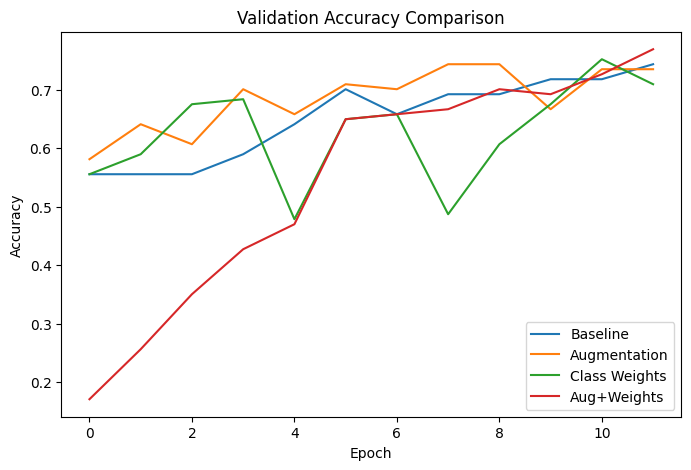

In [97]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['val_accuracy'],label="Baseline")
plt.plot(history_aug.history['val_accuracy'],label="Augmentation")
plt.plot(history_weights.history['val_accuracy'],label="Class Weights")
plt.plot(history_both.history['val_accuracy'],label="Aug+Weights")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

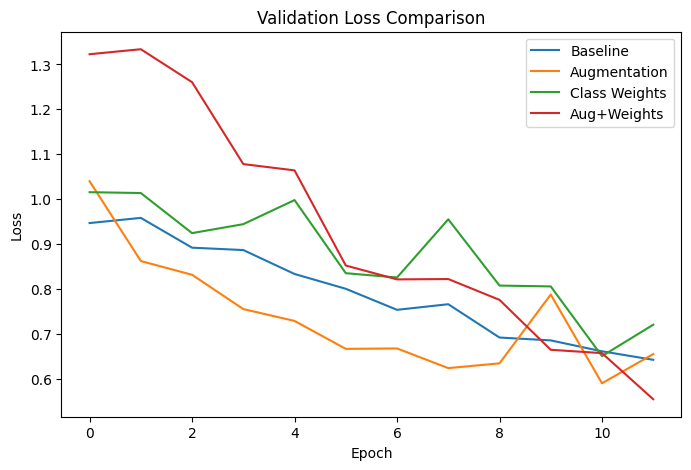

In [98]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['val_loss'],label="Baseline")
plt.plot(history_aug.history['val_loss'],label="Augmentation")
plt.plot(history_weights.history['val_loss'],label="Class Weights")
plt.plot(history_both.history['val_loss'],label="Aug+Weights")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7179 - loss: 0.7766
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6667 - loss: 0.8558
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6325 - loss: 0.8698
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7265 - loss: 0.7757


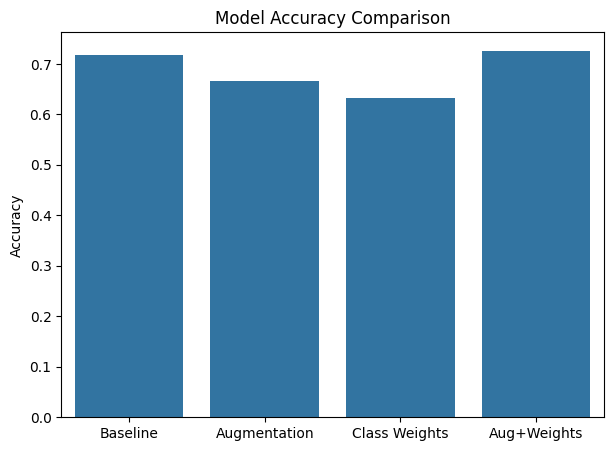

In [99]:
acc1 = model_baseline.evaluate(X_test,y_test)[1]
acc2 = model_aug.evaluate(X_test,y_test)[1]
acc3 = model_weights.evaluate(X_test,y_test)[1]
acc4 = model_both.evaluate(X_test,y_test)[1]

models = ["Baseline","Augmentation","Class Weights","Aug+Weights"]

accuracies = [acc1,acc2,acc3,acc4]

plt.figure(figsize=(7,5))

sns.barplot(x=models,y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()